
=== ENERGY PER LED ===

Illuminant 1
LED 00 | level 11 | sum=0.0048 | peak=0.0003
LED 01 | level 03 | sum=0.0220 | peak=0.0034
LED 02 | level 09 | sum=0.4935 | peak=0.0402
LED 03 | level 14 | sum=1.0011 | peak=0.0453
LED 04 | level 19 | sum=1.1287 | peak=0.0474
LED 05 | level 18 | sum=0.7072 | peak=0.0201
LED 06 | level 07 | sum=0.2212 | peak=0.0063
LED 07 | level 00 | sum=0.0355 | peak=0.0010
LED 08 | level 09 | sum=0.3712 | peak=0.0033
LED 09 | level 13 | sum=1.7604 | peak=0.0143
LED 10 | level 00 | sum=0.0105 | peak=0.0006
LED 11 | level 18 | sum=2.0964 | peak=0.0143
LED 12 | level 00 | sum=0.0269 | peak=0.0014
LED 13 | level 16 | sum=1.1538 | peak=0.0511
LED 14 | level 18 | sum=0.7067 | peak=0.0269
TOTAL ENERGY: 9.7397

Illuminant 2
LED 00 | level 10 | sum=0.0045 | peak=0.0003
LED 01 | level 09 | sum=0.0535 | peak=0.0079
LED 02 | level 01 | sum=0.1143 | peak=0.0091
LED 03 | level 03 | sum=0.2986 | peak=0.0144
LED 04 | level 01 | sum=0.1282 | peak=0.0062
LED 05 | level 06 | sum=0.3

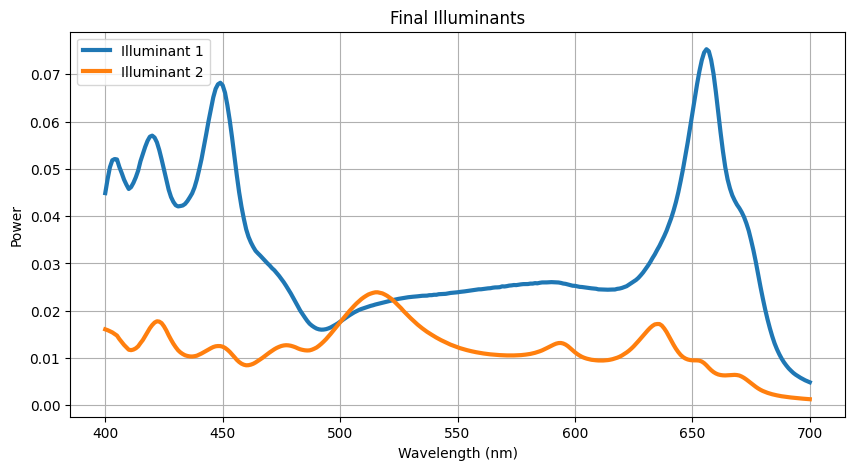

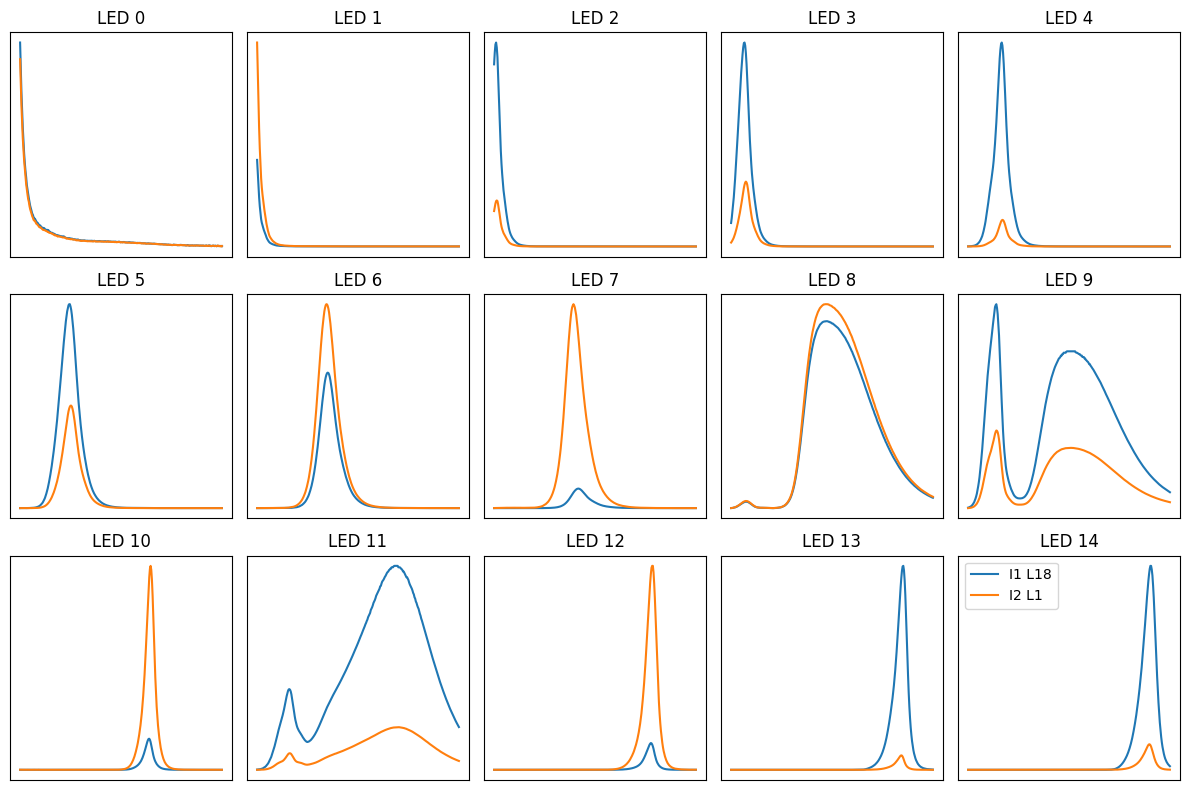

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from opt_network import load_led_library


# --------------------------------------------------
# INPUT
# --------------------------------------------------
led_path = "/Users/kolyszko/Documents/MATLAB/Thouslite5.mat"

choice_idx = torch.tensor([
    [11, 3, 9, 14, 19, 18, 7, 0, 9, 13, 0, 18, 0, 16, 18],
    [10, 9, 1, 3, 1, 6, 14, 15, 10, 4, 7, 2, 8, 0, 1]
])


# --------------------------------------------------
# LOAD LED LIBRARY
# --------------------------------------------------
led_library = load_led_library(mat_path=led_path)  # [15,20,L]

K, N_LED = choice_idx.shape
L = led_library.shape[-1]

# --------------------------------------------------
# COSTRUZIONE ILLUMINANTI
# --------------------------------------------------
illuminants = []

for k in range(K):
    curves = []

    for led in range(N_LED):
        idx = choice_idx[k, led]
        curve = led_library[led, idx]   # [L]
        curves.append(curve)

    curves = torch.stack(curves)        # [15,L]
    illuminant = curves.sum(dim=0)      # [L]

    illuminants.append(illuminant)

illuminants = torch.stack(illuminants)  # [2,L]

# --------------------------------------------------
# DEBUG ENERGIA PER LED
# --------------------------------------------------
print("\n=== ENERGY PER LED ===")

for k in range(K):
    print(f"\nIlluminant {k+1}")
    total = 0

    for led in range(N_LED):
        idx = choice_idx[k, led]
        curve = led_library[led, idx]

        energy = curve.sum().item()
        peak = curve.max().item()

        total += energy

        print(f"LED {led:02d} | level {int(idx):02d} | sum={energy:.4f} | peak={peak:.4f}")

    print(f"TOTAL ENERGY: {total:.4f}")


# --------------------------------------------------
# PLOT ILLUMINANTI FINALI
# --------------------------------------------------
wl = np.linspace(400, 700, L)

plt.figure(figsize=(10,5))

for k in range(K):
    plt.plot(
        wl,
        illuminants[k].cpu().numpy(),
        linewidth=3,
        label=f"Illuminant {k+1}"
    )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Power")
plt.title("Final Illuminants")
plt.legend()
plt.grid(True)
plt.show()


# --------------------------------------------------
# PLOT CONTRIBUTI PER LED (DEBUG CRUCIALE)
# --------------------------------------------------
plt.figure(figsize=(12,8))

for led in range(N_LED):

    plt.subplot(3,5,led+1)

    for k in range(K):
        idx = choice_idx[k, led]
        curve = led_library[led, idx]

        plt.plot(wl, curve.cpu().numpy(), label=f"I{k+1} L{int(idx)}")

    plt.title(f"LED {led}")
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.legend()
plt.show()

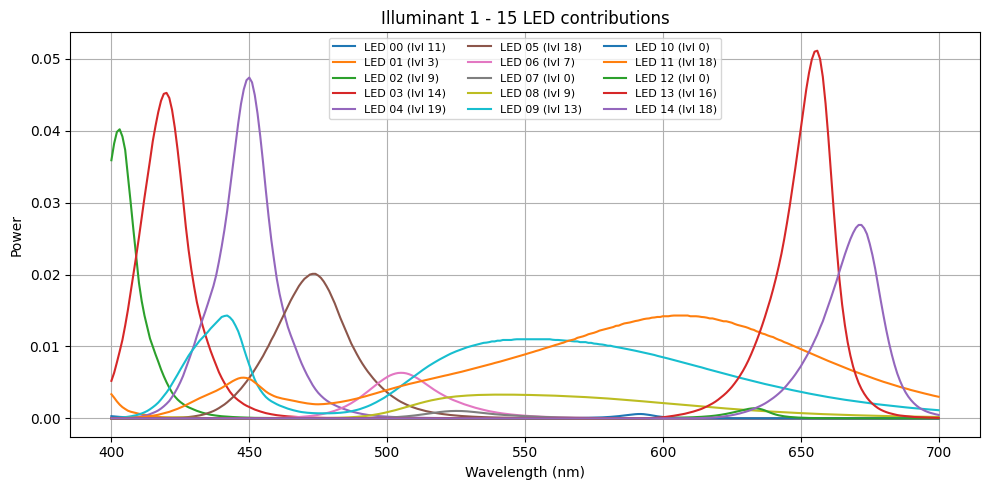

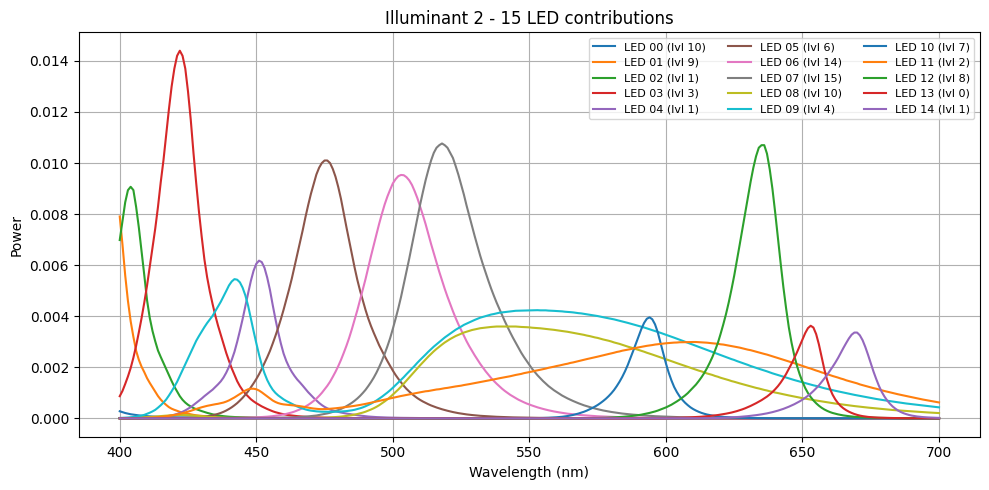

In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from opt_network import load_led_library


# --------------------------------------------------
# INPUT
# --------------------------------------------------
led_path = "/Users/kolyszko/Documents/MATLAB/Thouslite5.mat"

choice_idx = torch.tensor([
    [11, 3, 9, 14, 19, 18, 7, 0, 9, 13, 0, 18, 0, 16, 18],
    [10, 9, 1, 3, 1, 6, 14, 15, 10, 4, 7, 2, 8, 0, 1]
])

# --------------------------------------------------
# LOAD
# --------------------------------------------------
led_library = load_led_library(mat_path=led_path)   # [15,20,L]
L = led_library.shape[-1]
wl = np.linspace(400, 700, L)

# --------------------------------------------------
# PLOT
# --------------------------------------------------
K, N_LED = choice_idx.shape

for k in range(K):

    plt.figure(figsize=(10,5))

    for led in range(N_LED):
        idx = int(choice_idx[k, led])
        curve = led_library[led, idx].cpu().numpy()

        plt.plot(
            wl,
            curve,
            linewidth=1.5,
            label=f"LED {led:02d} (lvl {idx})"
        )

    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Power")
    plt.title(f"Illuminant {k+1} - 15 LED contributions")
    plt.grid(True)
    plt.legend(ncol=3, fontsize=8)
    plt.tight_layout()
    plt.show()

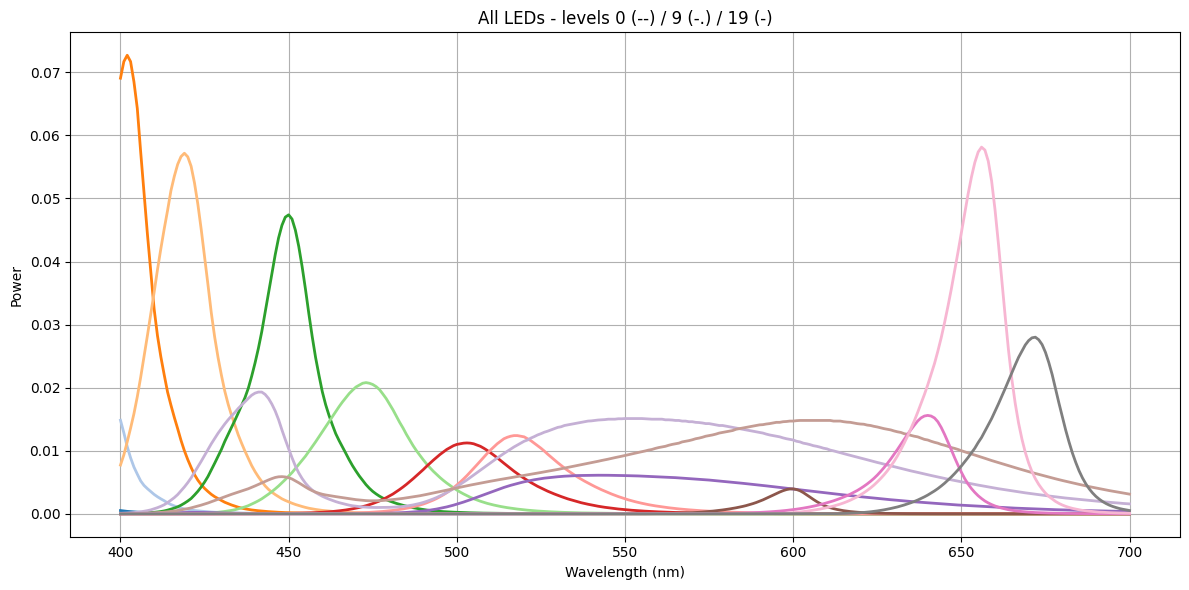

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from opt_network import load_led_library

# --------------------------------------------------
# PATH
# --------------------------------------------------
led_path = "/Users/kolyszko/Documents/MATLAB/Thouslite5.mat"

# --------------------------------------------------
# LOAD
# --------------------------------------------------
led_library = load_led_library(mat_path=led_path)   # [15,20,L]
L = led_library.shape[-1]
wl = np.linspace(400, 700, L)

num_led = led_library.shape[0]

plt.figure(figsize=(12,6))

for led in range(num_led):

    curve_19 = led_library[led, 19].cpu().numpy()

    # colori diversi per LED
    color = plt.cm.tab20(led)

    # line styles per livello
    plt.plot(wl, curve_19, linestyle="-", color=color, linewidth=2)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Power")
plt.title("All LEDs - levels 0 (--) / 9 (-.) / 19 (-)")
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def plot_illuminants_normalized(E1, E2, wavelengths=None, title="Normalized Illuminants"):
    """
    E1, E2: array [L] oppure torch tensor [L]
    wavelengths: opzionale, array [L] (es. 370–670)
    """

    # convert to numpy
    if hasattr(E1, "detach"):
        E1 = E1.detach().cpu().numpy()
    if hasattr(E2, "detach"):
        E2 = E2.detach().cpu().numpy()

    # normalizzazione indipendente
    E1_norm = E1 / (np.max(E1) + 1e-8)
    E2_norm = E2 / (np.max(E2) + 1e-8)

    # asse x
    if wavelengths is None:
        wavelengths = np.arange(len(E1))

    # plot
    plt.figure(figsize=(8, 5))
    plt.plot(wavelengths, E1_norm, label="Illuminant 1 (norm)", linewidth=2)
    plt.plot(wavelengths, E2_norm, label="Illuminant 2 (norm)", linewidth=2)

    plt.xlabel("Wavelength (nm)" if wavelengths is not None else "Index")
    plt.ylabel("Normalized Power")
    plt.title(title)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

Illuminant 1 -> sum: 9.832164764404297  max: 0.08437120914459229
Illuminant 2 -> sum: 2.351393222808838  max: 0.01975444331765175


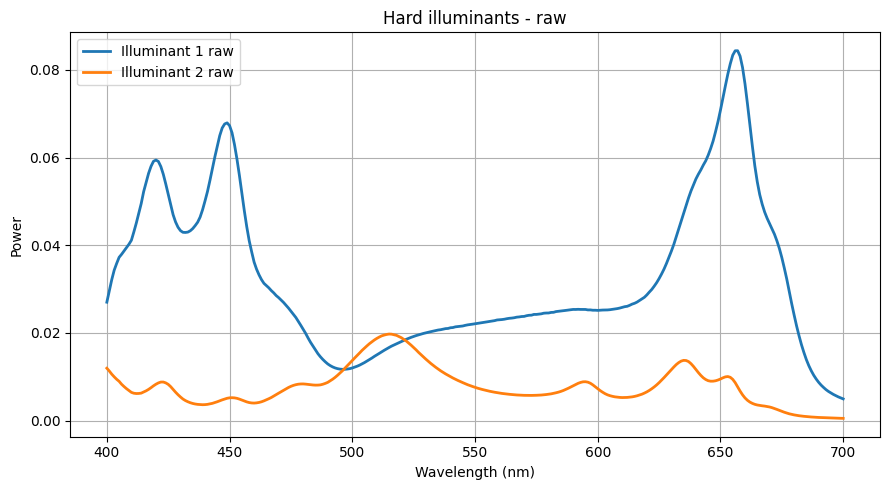

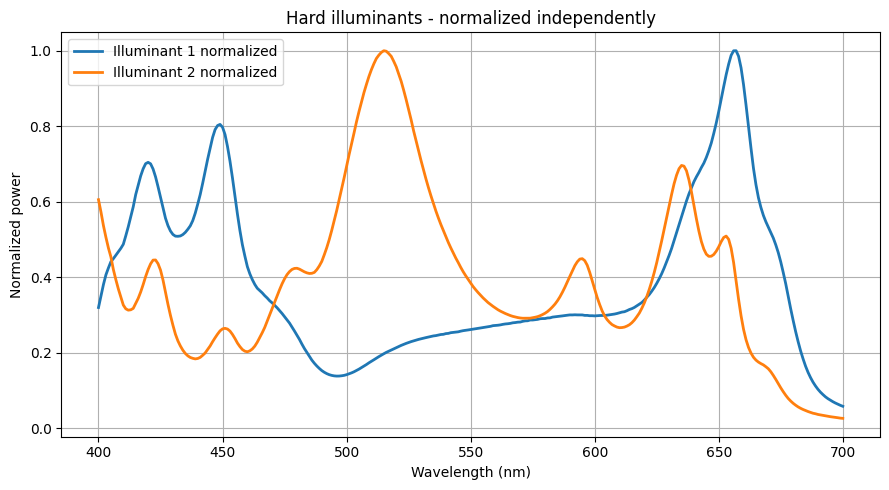

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from utils import load_led_library


def build_hard_illuminants(choice_idx, led_library):
    """
    choice_idx  : [K, 15]
    led_library : [15, 20, L]

    return:
        illuminants : [K, L]
    """
    K, num_leds = choice_idx.shape
    illuminants = []

    for k in range(K):
        curves = []
        for led in range(num_leds):
            idx = int(choice_idx[k, led])
            curves.append(led_library[led, idx])   # [L]

        curves = torch.stack(curves, dim=0)        # [15, L]
        illuminant = curves.sum(dim=0)             # [L]
        illuminants.append(illuminant)

    illuminants = torch.stack(illuminants, dim=0)  # [K, L]
    return illuminants


def plot_illuminants_normalized(E1, E2, wavelengths):
    """
    Normalizzazione indipendente per ciascun illuminante.
    """
    if torch.is_tensor(E1):
        E1 = E1.detach().cpu().numpy()
    if torch.is_tensor(E2):
        E2 = E2.detach().cpu().numpy()

    E1_norm = E1 / (E1.max() + 1e-8)
    E2_norm = E2 / (E2.max() + 1e-8)

    plt.figure(figsize=(9, 5))
    plt.plot(wavelengths, E1_norm, linewidth=2, label="Illuminant 1 normalized")
    plt.plot(wavelengths, E2_norm, linewidth=2, label="Illuminant 2 normalized")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Normalized power")
    plt.title("Hard illuminants - normalized independently")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_illuminants_raw(E1, E2, wavelengths):
    """
    Plot non normalizzato, per confrontare l'energia reale.
    """
    if torch.is_tensor(E1):
        E1 = E1.detach().cpu().numpy()
    if torch.is_tensor(E2):
        E2 = E2.detach().cpu().numpy()

    plt.figure(figsize=(9, 5))
    plt.plot(wavelengths, E1, linewidth=2, label="Illuminant 1 raw")
    plt.plot(wavelengths, E2, linewidth=2, label="Illuminant 2 raw")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Power")
    plt.title("Hard illuminants - raw")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def main():
    led_path = "/Users/kolyszko/Documents/MATLAB/Thouslite5.mat"

    # hard choices forniti da te
    choice_idx = torch.tensor([
        [12,  2,  4, 16, 19, 16,  0,  0,  3, 13,  0, 19, 16, 19, 19],
        [10,  9,  0,  1,  0,  3, 10, 15, 10,  0,  9,  0,  7,  1,  0]
    ], dtype=torch.long)

    # carica libreria LED
    led_library = load_led_library(mat_path=led_path)   # [15, 20, L]

    # costruisci illuminanti hard
    illuminants = build_hard_illuminants(choice_idx, led_library)   # [2, L]

    E1 = illuminants[0]
    E2 = illuminants[1]

    # asse x
    L = illuminants.shape[-1]
    wavelengths = np.linspace(400, 700, L)

    # stampa energia totale e picco
    print("Illuminant 1 -> sum:", E1.sum().item(), " max:", E1.max().item())
    print("Illuminant 2 -> sum:", E2.sum().item(), " max:", E2.max().item())

    # plot raw
    plot_illuminants_raw(E1, E2, wavelengths)

    # plot normalizzato singolarmente
    plot_illuminants_normalized(E1, E2, wavelengths)


if __name__ == "__main__":
    main()

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from utils import load_led_library, load_camera_SPD


# =========================
# HARD CHOICES
# =========================
choice_idx = torch.tensor([
    [12,  2,  0, 19, 19, 12,  1,  0,  8,  9,  0, 15,  0, 19, 19],
    [10,  9,  0,  1,  0,  3, 10, 15, 10,  0,  9,  0,  6,  0,  0]
], dtype=torch.long)


# =========================
# BUILD ILLUMINANTS
# =========================
def build_hard_illuminants(choice_idx, led_library):
    K, num_leds = choice_idx.shape
    illuminants = []

    for k in range(K):
        curves = []
        for led in range(num_leds):
            idx = int(choice_idx[k, led])
            curves.append(led_library[led, idx])  # [L]

        curves = torch.stack(curves, dim=0)       # [15, L]
        illuminant = curves.sum(dim=0)            # [L]
        illuminants.append(illuminant)

    return torch.stack(illuminants, dim=0)        # [K, L]


# =========================
# RENDER RGB
# =========================
def render_rgb(hsi, illuminant, sensitivity):
    """
    hsi: [H, W, L]
    illuminant: [L]
    sensitivity: [3, L]

    return: [H, W, 3]
    """
    H, W, L = hsi.shape

    E = illuminant.view(1, 1, L)
    S = sensitivity.view(1, 1, 3, L)

    # [H,W,L] * [1,1,L] -> [H,W,L]
    radiance = hsi * E

    # expand for channels
    radiance = radiance.unsqueeze(2)  # [H,W,1,L]

    # integrate
    rgb = (radiance * S).sum(dim=-1)  # [H,W,3]

    return rgb


# =========================
# VISUALIZATION
# =========================
def visualize_rgb(rgb1, rgb2):

    rgb1 = rgb1.detach().cpu().numpy()
    rgb2 = rgb2.detach().cpu().numpy()

    rgb1 = np.clip(rgb1, 0, None)
    rgb2 = np.clip(rgb2, 0, None)

    def minmax(x):
        return (x - x.min()) / (x.max() - x.min() + 1e-8)

    max_val = max(rgb1.max(), rgb2.max())

    print("RGB1:", rgb1.min(), rgb1.max(), rgb1.mean())
    print("RGB2:", rgb2.min(), rgb2.max(), rgb2.mean())

    plt.figure(figsize=(12, 9))

    # RAW
    plt.subplot(3, 2, 1)
    plt.imshow(rgb1)
    plt.title("RGB1 RAW")
    plt.axis("off")

    plt.subplot(3, 2, 2)
    plt.imshow(rgb2)
    plt.title("RGB2 RAW")
    plt.axis("off")

    # MINMAX
    plt.subplot(3, 2, 3)
    plt.imshow(minmax(rgb1))
    plt.title("RGB1 MINMAX")
    plt.axis("off")

    plt.subplot(3, 2, 4)
    plt.imshow(minmax(rgb2))
    plt.title("RGB2 MINMAX")
    plt.axis("off")

    # SAME SCALE
    plt.subplot(3, 2, 5)
    plt.imshow(rgb1 / (max_val + 1e-8))
    plt.title("RGB1 SAME SCALE")
    plt.axis("off")

    plt.subplot(3, 2, 6)
    plt.imshow(rgb2 / (max_val + 1e-8))
    plt.title("RGB2 SAME SCALE")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# =========================
# MAIN
# =========================
def main():

    # --- carica dati ---
    led_library = load_led_library("/Users/kolyszko/Documents/MATLAB/Thouslite5.mat")   # [15,20,L]
    sensitivity = load_camera_SPD("/Users/kolyszko/Documents/NIKON-D810.csv")            # [3,L]

    # esempio: carica una HSI [H,W,L]
    hsi = torch.load("sample_hsi.pt")  # devi mettere un tuo file

    # --- costruisci illuminanti ---
    illuminants = build_hard_illuminants(choice_idx, led_library)

    E1 = illuminants[0]
    E2 = illuminants[1]

    # --- render ---
    rgb1 = render_rgb(hsi, E1, sensitivity)
    rgb2 = render_rgb(hsi, E2, sensitivity)

    # --- visualizza ---
    visualize_rgb(rgb1, rgb2)


if __name__ == "__main__":
    main()

In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np

from opt_network import *
from dataset import *
from utils import *


def build_hard_illuminants(model):
    """
    Costruisce gli illuminanti hard a partire dai logits
    """
    led_library = model.ill_optimizer.led_library  # [15,20,L]

    # logits dal modello (MLP version)
    _, logits = model.ill_optimizer(return_logits=True)

    # scelta hard
    choice_idx = torch.argmax(logits, dim=-1)  # [K,15]

    print("Hard LED choices:")
    print(choice_idx)

    hard_illuminants = []

    for k in range(choice_idx.shape[0]):
        curves = []

        for led in range(15):
            idx = choice_idx[k, led]
            curves.append(led_library[led, idx])

        curves = torch.stack(curves)       # [15,L]
        illuminant = curves.sum(dim=0)     # [L]

        hard_illuminants.append(illuminant)

    return torch.stack(hard_illuminants)   # [K,L]


def visualize_rgb(rgb1, rgb2):
    """
    3 visualizzazioni:
    1. RAW
    2. MINMAX separata per immagine
    3. SAME SCALE tra le due immagini
    """

    # clamp solo sotto a 0, non sopra
    rgb1 = np.clip(rgb1, 0, None)
    rgb2 = np.clip(rgb2, 0, None)

    def minmax(x):
        return (x - x.min()) / (x.max() - x.min() + 1e-8)

    max_val = max(rgb1.max(), rgb2.max())

    print("RGB1 -> min:", rgb1.min(), " max:", rgb1.max(), " mean:", rgb1.mean())
    print("RGB2 -> min:", rgb2.min(), " max:", rgb2.max(), " mean:", rgb2.mean())

    plt.figure(figsize=(12, 9))

    # -------------------------
    # 1. RAW
    # -------------------------
    plt.subplot(3, 2, 1)
    plt.imshow(rgb1)
    plt.title("RGB1 - RAW")
    plt.axis("off")

    plt.subplot(3, 2, 2)
    plt.imshow(rgb2)
    plt.title("RGB2 - RAW")
    plt.axis("off")

    # -------------------------
    # 2. MINMAX per immagine
    # -------------------------
    plt.subplot(3, 2, 3)
    plt.imshow(minmax(rgb1))
    plt.title("RGB1 - MINMAX")
    plt.axis("off")

    plt.subplot(3, 2, 4)
    plt.imshow(minmax(rgb2))
    plt.title("RGB2 - MINMAX")
    plt.axis("off")

    # -------------------------
    # 3. SAME SCALE
    # -------------------------
    plt.subplot(3, 2, 5)
    plt.imshow(rgb1 / (max_val + 1e-8))
    plt.title("RGB1 - SAME SCALE")
    plt.axis("off")

    plt.subplot(3, 2, 6)
    plt.imshow(rgb2 / (max_val + 1e-8))
    plt.title("RGB2 - SAME SCALE")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


def main():

    # --------------------------------------------------
    # paths
    # --------------------------------------------------
    checkpoint_path = "/Users/kolyszko/Scrivania/run_12_random_crop/jointnet-epoch=816-val_loss=0.0636.ckpt"
    led_path = "/Users/kolyszko/Documents/MATLAB/Thouslite5.mat"
    camera_path = "/Users/kolyszko/Documents/NIKON-D810.csv"
    data_dir = "/Volumes/Lexar/31bands_h5"

    # --------------------------------------------------
    # load model
    # --------------------------------------------------
    model = JointNetwork.load_from_checkpoint(
        checkpoint_path,
        lr=1e-3,
        patience=50,
        model_type=2,
        n_ill=2,
        in_dim=6,
        lambda_ang=0.2,
        led_path=led_path,
        camera_spd_path=camera_path
    )

    model.eval()

    # --------------------------------------------------
    # dataset (prendo un sample)
    # --------------------------------------------------
    dataset = H5ReflectanceDataset(folder_path=data_dir, dtype=torch.float32)
    ref = dataset[5].unsqueeze(0)   # [1,31,H,W]

    # --------------------------------------------------
    # hard illuminants
    # --------------------------------------------------
    hard_ills = build_hard_illuminants(model)  # [2,L]

    # --------------------------------------------------
    # rendering RGB
    # --------------------------------------------------
    rgb1, rgb2 = render_rgb(ref, hard_ills, camera_path)

    # [1,3,H,W] -> [H,W,3]
    rgb1 = rgb1[0].permute(1, 2, 0).detach().cpu().numpy()
    rgb2 = rgb2[0].permute(1, 2, 0).detach().cpu().numpy()

    # --------------------------------------------------
    # 3 visualizzazioni
    # --------------------------------------------------
    visualize_rgb(rgb1, rgb2)


if __name__ == "__main__":
    main()

RuntimeError: Error(s) in loading state_dict for JointNetwork:
	Missing key(s) in state_dict: "net.mlp.0.weight", "net.mlp.0.bias", "net.mlp.2.weight", "net.mlp.2.bias", "net.mlp.4.weight", "net.mlp.4.bias". 
	Unexpected key(s) in state_dict: "net.conv_in.weight", "net.body.0.embedding.weight", "net.body.0.encoder_layers.0.0.blocks.0.0.rescale", "net.body.0.encoder_layers.0.0.blocks.0.0.to_q.weight", "net.body.0.encoder_layers.0.0.blocks.0.0.to_k.weight", "net.body.0.encoder_layers.0.0.blocks.0.0.to_v.weight", "net.body.0.encoder_layers.0.0.blocks.0.0.proj.weight", "net.body.0.encoder_layers.0.0.blocks.0.0.proj.bias", "net.body.0.encoder_layers.0.0.blocks.0.0.pos_emb.0.weight", "net.body.0.encoder_layers.0.0.blocks.0.0.pos_emb.2.weight", "net.body.0.encoder_layers.0.0.blocks.0.1.fn.net.0.weight", "net.body.0.encoder_layers.0.0.blocks.0.1.fn.net.2.weight", "net.body.0.encoder_layers.0.0.blocks.0.1.fn.net.4.weight", "net.body.0.encoder_layers.0.0.blocks.0.1.norm.weight", "net.body.0.enco

Hard LED choices:
tensor([[12,  2,  4, 16, 19, 16,  0,  0,  3, 13,  0, 19, 16, 19, 19],
        [10,  9,  0,  1,  0,  3, 10, 15, 10,  0,  9,  0,  7,  1,  0]])
RGB1 -> min: 0.00094844674  max: 0.26133013  mean: 0.026648963
RGB2 -> min: 0.0002351794  max: 0.099752665  mean: 0.008642491


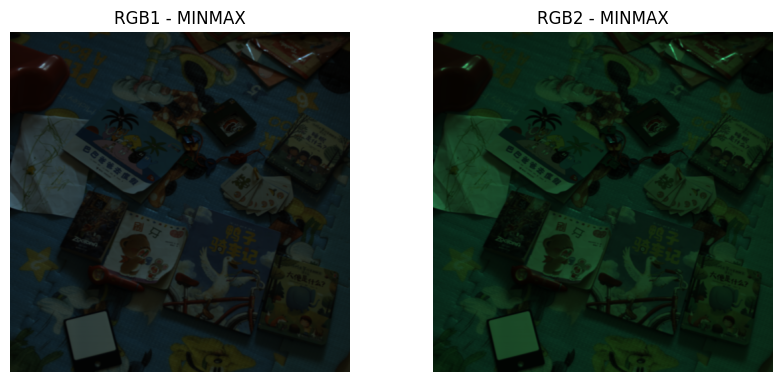

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np

from opt_network import *
from dataset import *
from utils import *


def build_hard_illuminants(model):
    """
    Costruisce gli illuminanti hard a partire dai logits
    """
    led_library = model.ill_optimizer.led_library  # [15,20,L]

    # logits dal modello (MLP version)
    _, logits = model.ill_optimizer(return_logits=True)

    # scelta hard
    choice_idx = torch.argmax(logits, dim=-1)  # [K,15]

    print("Hard LED choices:")
    print(choice_idx)

    hard_illuminants = []

    for k in range(choice_idx.shape[0]):
        curves = []

        for led in range(15):
            idx = choice_idx[k, led]
            curves.append(led_library[led, idx])

        curves = torch.stack(curves)       # [15,L]
        illuminant = curves.sum(dim=0)     # [L]

        hard_illuminants.append(illuminant)

    return torch.stack(hard_illuminants)   # [K,L]


def visualize_rgb(rgb1, rgb2):
    """
    3 visualizzazioni:
    1. RAW
    2. MINMAX separata per immagine
    3. SAME SCALE tra le due immagini
    """

    # clamp solo sotto a 0, non sopra
    rgb1 = np.clip(rgb1, 0, None)
    rgb2 = np.clip(rgb2, 0, None)
    rgb1 = np.rot90(rgb1, k=-1)
    rgb2 = np.rot90(rgb2, k=-1)

    def minmax(x):
        return (x - x.min()) / (x.max() - x.min() + 1e-8)

    max_val = max(rgb1.max(), rgb2.max())

    print("RGB1 -> min:", rgb1.min(), " max:", rgb1.max(), " mean:", rgb1.mean())
    print("RGB2 -> min:", rgb2.min(), " max:", rgb2.max(), " mean:", rgb2.mean())

    plt.figure(figsize=(10, 15))

    # -------------------------
    # 2. MINMAX per immagine
    # -------------------------
    plt.subplot(3, 2, 3)
    plt.imshow(minmax(rgb1))
    plt.title("RGB1 - MINMAX")
    plt.axis("off")

    plt.subplot(3, 2, 4)
    plt.imshow(minmax(rgb2))
    plt.title("RGB2 - MINMAX")
    plt.axis("off")


def main():

    # --------------------------------------------------
    # paths
    # --------------------------------------------------
    checkpoint_path = "/Users/kolyszko/Scrivania/run_12_random_crop/jointnet-epoch=816-val_loss=0.0636.ckpt"
    led_path = "/Users/kolyszko/Documents/MATLAB/Thouslite5.mat"
    camera_path = "/Users/kolyszko/Documents/Dottorato/Progetti/Illuminant_optimization/data/NIKON-D810.csv"
    data_dir = "/Volumes/Lexar/31bands_h5"

    # --------------------------------------------------
    # load model
    # --------------------------------------------------
    model = JointNetwork.load_from_checkpoint(
        checkpoint_path,
        lr=1e-3,
        patience=50,
        model_type=3,
        n_ill=2,
        in_dim=6,
        lambda_ang=0.2,
        led_path=led_path,
        camera_spd_path=camera_path
    )

    model.eval()

    # --------------------------------------------------
    # dataset (prendo un sample)
    # --------------------------------------------------
    dataset = H5ReflectanceDataset(folder_path=data_dir, dtype=torch.float32)
    ref = dataset[5].unsqueeze(0)   # [1,31,H,W]

    # --------------------------------------------------
    # hard illuminants
    # --------------------------------------------------
    hard_ills = build_hard_illuminants(model)  # [2,L]

    # --------------------------------------------------
    # rendering RGB
    # --------------------------------------------------
    rgb1, rgb2 = render_rgb(ref, hard_ills, camera_path)

    # [1,3,H,W] -> [H,W,3]
    rgb1 = rgb1[0].permute(1, 2, 0).detach().cpu().numpy()
    rgb2 = rgb2[0].permute(1, 2, 0).detach().cpu().numpy()

    # --------------------------------------------------
    # 3 visualizzazioni
    # --------------------------------------------------
    visualize_rgb(rgb1, rgb2)


if __name__ == "__main__":
    main()

In [1]:
print('ciao')

ciao


Hard LED choices:
tensor([[10,  0, 17, 19, 18, 15,  2,  0,  6, 13,  0,  2, 19, 19,  3],
        [14, 19,  0,  0,  0,  0,  6, 17,  1,  0,  9,  0, 11,  4, 19]])
RGB1 -> min: 0.0009148349  max: 0.24681936  mean: 0.021514721
RGB2 -> min: 0.00016573936  max: 0.075656  mean: 0.007432813


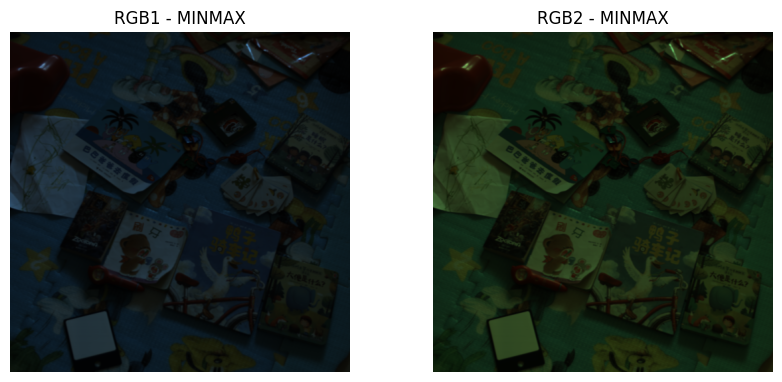

In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np

from opt_network import *
from dataset import *
from utils import *


def build_hard_illuminants(model):
    """
    Costruisce gli illuminanti hard a partire dai logits
    """
    led_library = model.ill_optimizer.led_library  # [15,20,L]

    # logits dal modello (MLP version)
    _, logits = model.ill_optimizer(return_logits=True)

    # scelta hard
    choice_idx = torch.argmax(logits, dim=-1)  # [K,15]

    print("Hard LED choices:")
    print(choice_idx)

    hard_illuminants = []

    for k in range(choice_idx.shape[0]):
        curves = []

        for led in range(15):
            idx = choice_idx[k, led]
            curves.append(led_library[led, idx])

        curves = torch.stack(curves)       # [15,L]
        illuminant = curves.sum(dim=0)     # [L]

        hard_illuminants.append(illuminant)

    return torch.stack(hard_illuminants)   # [K,L]


def visualize_rgb(rgb1, rgb2):
    """
    3 visualizzazioni:
    1. RAW
    2. MINMAX separata per immagine
    3. SAME SCALE tra le due immagini
    """

    # clamp solo sotto a 0, non sopra
    rgb1 = np.clip(rgb1, 0, None)
    rgb2 = np.clip(rgb2, 0, None)
    rgb1 = np.rot90(rgb1, k=-1)
    rgb2 = np.rot90(rgb2, k=-1)

    def minmax(x):
        return (x - x.min()) / (x.max() - x.min() + 1e-8)

    max_val = max(rgb1.max(), rgb2.max())

    print("RGB1 -> min:", rgb1.min(), " max:", rgb1.max(), " mean:", rgb1.mean())
    print("RGB2 -> min:", rgb2.min(), " max:", rgb2.max(), " mean:", rgb2.mean())

    plt.figure(figsize=(10, 15))

    # -------------------------
    # 2. MINMAX per immagine
    # -------------------------
    plt.subplot(3, 2, 3)
    plt.imshow(minmax(rgb1))
    plt.title("RGB1 - MINMAX")
    plt.axis("off")

    plt.subplot(3, 2, 4)
    plt.imshow(minmax(rgb2))
    plt.title("RGB2 - MINMAX")
    plt.axis("off")


def main():

    # --------------------------------------------------
    # paths
    # --------------------------------------------------
    checkpoint_path = "/Users/kolyszko/Scrivania/run_13_sony/jointnet-epoch=447-val_loss=0.0758.ckpt"
    led_path = "/Users/kolyszko/Documents/MATLAB/Thouslite5.mat"
    camera_path = "/Users/kolyszko/Documents/NIKON-D810.csv"
    data_dir = "/Volumes/Lexar/31bands_h5"

    # --------------------------------------------------
    # load model
    # --------------------------------------------------
    model = JointNetwork.load_from_checkpoint(
        checkpoint_path,
        lr=1e-3,
        patience=50,
        model_type=3,
        n_ill=2,
        in_dim=6,
        lambda_ang=0.2,
        led_path=led_path,
        camera_spd_path=camera_path
    )

    model.eval()

    # --------------------------------------------------
    # dataset (prendo un sample)
    # --------------------------------------------------
    dataset = H5ReflectanceDataset(folder_path=data_dir, dtype=torch.float32)
    ref = dataset[5].unsqueeze(0)   # [1,31,H,W]

    # --------------------------------------------------
    # hard illuminants
    # --------------------------------------------------
    hard_ills = build_hard_illuminants(model)  # [2,L]

    # --------------------------------------------------
    # rendering RGB
    # --------------------------------------------------
    rgb1, rgb2 = render_rgb(ref, hard_ills, camera_path)

    # [1,3,H,W] -> [H,W,3]
    rgb1 = rgb1[0].permute(1, 2, 0).detach().cpu().numpy()
    rgb2 = rgb2[0].permute(1, 2, 0).detach().cpu().numpy()

    # --------------------------------------------------
    # 3 visualizzazioni
    # --------------------------------------------------
    visualize_rgb(rgb1, rgb2)


if __name__ == "__main__":
    main()

Illuminant 1 -> sum: 8.29319953918457  max: 0.0802931934595108
Illuminant 2 -> sum: 2.820810079574585  max: 0.03018626570701599


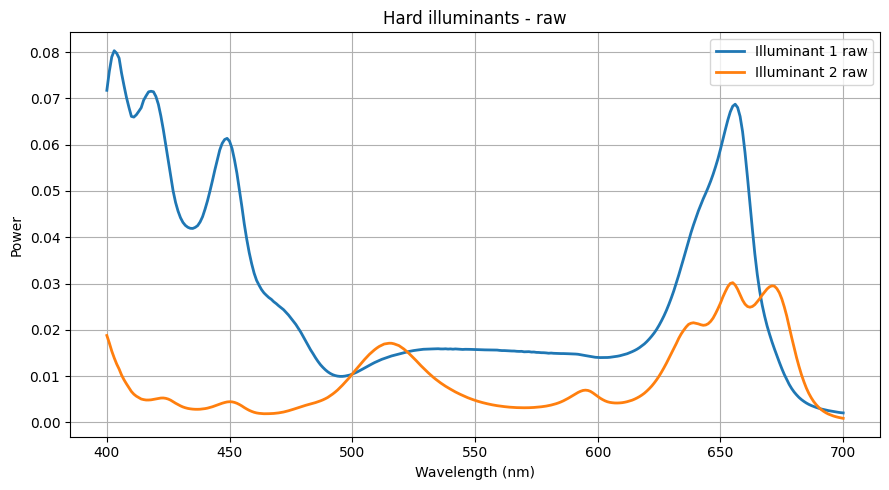

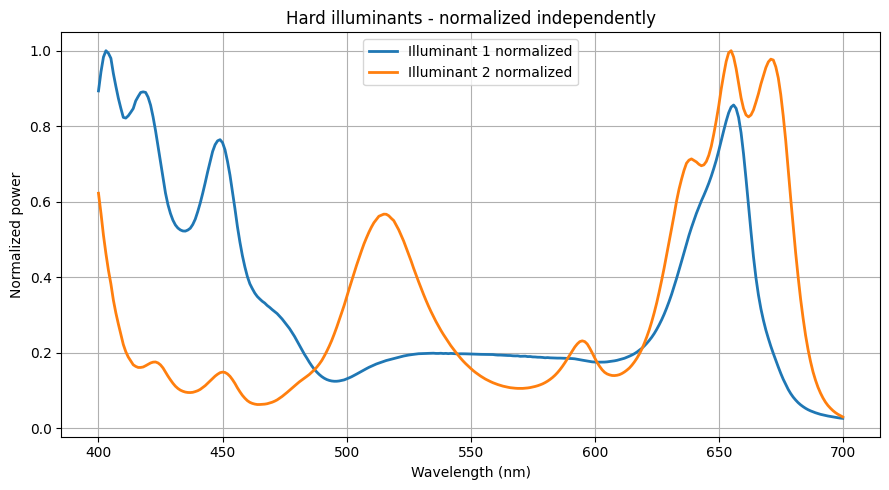

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from utils import load_led_library


def build_hard_illuminants(choice_idx, led_library):
    """
    choice_idx  : [K, 15]
    led_library : [15, 20, L]

    return:
        illuminants : [K, L]
    """
    K, num_leds = choice_idx.shape
    illuminants = []

    for k in range(K):
        curves = []
        for led in range(num_leds):
            idx = int(choice_idx[k, led])
            curves.append(led_library[led, idx])   # [L]

        curves = torch.stack(curves, dim=0)        # [15, L]
        illuminant = curves.sum(dim=0)             # [L]
        illuminants.append(illuminant)

    illuminants = torch.stack(illuminants, dim=0)  # [K, L]
    return illuminants


def plot_illuminants_normalized(E1, E2, wavelengths):
    """
    Normalizzazione indipendente per ciascun illuminante.
    """
    if torch.is_tensor(E1):
        E1 = E1.detach().cpu().numpy()
    if torch.is_tensor(E2):
        E2 = E2.detach().cpu().numpy()

    E1_norm = E1 / (E1.max() + 1e-8)
    E2_norm = E2 / (E2.max() + 1e-8)

    plt.figure(figsize=(9, 5))
    plt.plot(wavelengths, E1_norm, linewidth=2, label="Illuminant 1 normalized")
    plt.plot(wavelengths, E2_norm, linewidth=2, label="Illuminant 2 normalized")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Normalized power")
    plt.title("Hard illuminants - normalized independently")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_illuminants_raw(E1, E2, wavelengths):
    """
    Plot non normalizzato, per confrontare l'energia reale.
    """
    if torch.is_tensor(E1):
        E1 = E1.detach().cpu().numpy()
    if torch.is_tensor(E2):
        E2 = E2.detach().cpu().numpy()

    plt.figure(figsize=(9, 5))
    plt.plot(wavelengths, E1, linewidth=2, label="Illuminant 1 raw")
    plt.plot(wavelengths, E2, linewidth=2, label="Illuminant 2 raw")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Power")
    plt.title("Hard illuminants - raw")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def main():
    led_path = "/Users/kolyszko/Documents/MATLAB/Thouslite5.mat"

    # hard choices forniti da te
    choice_idx = torch.tensor([
        [10,  0, 17, 19, 18, 15,  2,  0,  6, 13,  0,  2, 19, 19,  3],
        [14, 19,  0,  0,  0,  0,  6, 17,  1,  0,  9,  0, 11,  4, 19]
    ], dtype=torch.long)

    # carica libreria LED
    led_library = load_led_library(mat_path=led_path)   # [15, 20, L]

    # costruisci illuminanti hard
    illuminants = build_hard_illuminants(choice_idx, led_library)   # [2, L]

    E1 = illuminants[0]
    E2 = illuminants[1]

    # asse x
    L = illuminants.shape[-1]
    wavelengths = np.linspace(400, 700, L)

    # stampa energia totale e picco
    print("Illuminant 1 -> sum:", E1.sum().item(), " max:", E1.max().item())
    print("Illuminant 2 -> sum:", E2.sum().item(), " max:", E2.max().item())

    # plot raw
    plot_illuminants_raw(E1, E2, wavelengths)

    # plot normalizzato singolarmente
    plot_illuminants_normalized(E1, E2, wavelengths)


if __name__ == "__main__":
    main()

In [14]:
def illumination_diversity_loss(combined_illum_list):
    loss = 0.0
    num_pairs = 0
    for i in range(len(combined_illum_list)):
        for j in range(i + 1, len(combined_illum_list)):
            diff = torch.abs(combined_illum_list[i] - combined_illum_list[j])
            loss += 1.0 / (diff.mean() + 1e-6)
            num_pairs += 1
    return loss / (num_pairs + 1e-6)

def illumination_trend_dissimilarity_loss(combined_illum_list):
    """
    Encourage different trend (derivative) across combined illuminations.
    """
    loss = 0.0
    num_pairs = 0
    for i in range(len(combined_illum_list)):
        for j in range(i + 1, len(combined_illum_list)):
            d1 = torch.diff(combined_illum_list[i], dim=0)
            d2 = torch.diff(combined_illum_list[j], dim=0)
            diff = torch.abs(d1 - d2)
            loss += 1.0 / (diff.mean() + 1e-6)
            num_pairs += 1
    return loss / (num_pairs + 1e-6)

def illumination_nonzero_response_loss(combined_illum_list, min_thresh=0.15, max_thresh=1.8):
    """
    Penalize too-small responses and (lightly) very large responses.
    """
    loss = 0.0
    for illum in combined_illum_list:
        low_mask = illum < min_thresh
        low_loss = (1.0 / (illum + 1e-6)) * low_mask.float()
        # high_loss = F.relu(illum - max_thresh)  # optional soft cap
        loss += low_loss.mean()
    return loss / len(combined_illum_list)

def build_hard_illuminants(choice_idx, led_library):
    """
    choice_idx  : [K, 15]
    led_library : [15, 20, L]

    return:
        illuminants : [K, L]
    """
    K, num_leds = choice_idx.shape
    illuminants = []

    for k in range(K):
        curves = []
        for led in range(num_leds):
            idx = int(choice_idx[k, led])
            curves.append(led_library[led, idx])   # [L]

        curves = torch.stack(curves, dim=0)        # [15, L]
        illuminant = curves.sum(dim=0)             # [L]
        illuminants.append(illuminant)

    illuminants = torch.stack(illuminants, dim=0)  # [K, L]
    return illuminants

led_path = "/Users/kolyszko/Documents/MATLAB/Thouslite5.mat"

# hard choices forniti da te
choice_idx = torch.tensor([
    [10,  0, 17, 19, 18, 15,  2,  0,  6, 13,  0,  2, 19, 19,  3],
    [14, 19,  0,  0,  0,  0,  6, 17,  1,  0,  9,  0, 11,  4, 19]
], dtype=torch.long)

# carica libreria LED
led_library = load_led_library(mat_path=led_path)   # [15, 20, L]

# costruisci illuminanti hard
illuminants = build_hard_illuminants(choice_idx, led_library)   # [2, L]

loss_div = illumination_diversity_loss(illuminants)
loss_trend = illumination_diversity_loss(illuminants)
loss_non_zero = illumination_nonzero_response_loss(illuminants)

print(f"Diversity loss: {loss_div}")
print(f"Trend loss: {loss_trend}")
print(f"NonZero loss: {loss_non_zero}")

Diversity loss: 50.634117126464844
Trend loss: 50.634117126464844
NonZero loss: 134.06204223632812


In [4]:
import kornia.color as kcolor
import torch
import matplotlib.pyplot as plt
import numpy as np

from opt_network import *
from dataset import *
from utils import *

def build_hard_illuminants(choice_idx, led_library):
    """
    choice_idx  : [K, 15]
    led_library : [15, 20, L]

    return:
        illuminants : [K, L]
    """
    K, num_leds = choice_idx.shape
    illuminants = []

    for k in range(K):
        curves = []
        for led in range(num_leds):
            idx = int(choice_idx[k, led])
            curves.append(led_library[led, idx])   # [L]

        curves = torch.stack(curves, dim=0)        # [15, L]
        illuminant = curves.sum(dim=0)             # [L]
        illuminants.append(illuminant)

    illuminants = torch.stack(illuminants, dim=0)  # [K, L]
    return illuminants

def rgb_to_lab(rgb):
    """
    rgb: (B, 3, H, W) in [0,1] -> Lab
    """
    rgb = rgb.clamp(0, 1)
    return kcolor.rgb_to_lab(rgb)

def rgb_to_chromaticity(rgb):
    intensity = rgb.sum(dim=1, keepdim=True) + 1e-6
    return rgb / intensity

def illumination_render_difference_pixelwise_loss(rgb_out_list):
    loss = 0.0
    num_pairs = 0
    for i in range(len(rgb_out_list)):
        for j in range(i + 1, len(rgb_out_list)):
            diff = torch.abs(rgb_out_list[i] - rgb_out_list[j])
            loss += 1.0 / (diff.mean() + 1e-6)
            num_pairs += 1
    return loss / (num_pairs + 1e-6)

def illumination_render_difference_color_loss(rgb_out_list):
    loss = 0.0
    num_pairs = 0
    for i in range(len(rgb_out_list)):
        for j in range(i + 1, len(rgb_out_list)):
            rgb_i_lab = rgb_to_lab(rgb_out_list[i])
            rgb_j_lab = rgb_to_lab(rgb_out_list[j])
            diff = torch.abs(rgb_i_lab - rgb_j_lab)
            loss += 1.0 / (diff.mean() + 1e-6)
            num_pairs += 1
    return loss / (num_pairs + 1e-6)

def illumination_render_difference_chromaticity_loss(rgb_out_list):
    loss = 0.0
    num_pairs = 0
    for i in range(len(rgb_out_list)):
        for j in range(i + 1, len(rgb_out_list)):
            chroma_i = rgb_to_chromaticity(rgb_out_list[i])
            chroma_j = rgb_to_chromaticity(rgb_out_list[j])
            diff = torch.abs(chroma_i - chroma_j)
            loss += 1.0 / (diff.mean() + 1e-6)
            num_pairs += 1
    return loss / (num_pairs + 1e-6)

led_path = "/Users/kolyszko/Documents/MATLAB/Thouslite5.mat"
camera_path = '/Users/kolyszko/Documents/Dottorato/Progetti/Illuminant_optimization/data/NIKON-D810.csv'
data_dir = "/Volumes/Lexar/31bands_h5"

# hard choices forniti da te
choice_idx = torch.tensor([
    [10,  0, 17, 19, 18, 15,  2,  0,  6, 13,  0,  2, 19, 19,  3],
    [14, 19,  0,  0,  0,  0,  6, 17,  1,  0,  9,  0, 11,  4, 19]
], dtype=torch.long)

# carica libreria LED
led_library = load_led_library(mat_path=led_path)   # [15, 20, L]

# costruisci illuminanti hard
illuminants = build_hard_illuminants(choice_idx, led_library)   # [2, L]

dataset = H5ReflectanceDataset(folder_path=data_dir, dtype=torch.float32)
ref = dataset[5].unsqueeze(0)   # [1,31,H,W]

# --------------------------------------------------
# rendering RGB
# --------------------------------------------------
rgb1, rgb2 = render_rgb(ref, illuminants, camera_path)

pixel_loss = illumination_render_difference_pixelwise_loss([rgb1, rgb2])
color_loss = illumination_render_difference_color_loss([rgb1, rgb2])
chroma_loss = illumination_render_difference_chromaticity_loss([rgb1, rgb2])

print(f"Pixel loss: {pixel_loss}")
print(f"Color loss: {color_loss}")
print(f"Chroma loss: {chroma_loss}")

Pixel loss: 71.00797271728516
Color loss: 1.5127533674240112
Chroma loss: 8.874324798583984


In [ ]:
import torch.nn as nn
class IlluminationRegularizationLoss(nn.Module):
    """
    Composite regularizer over combined illumination spectra and rendered RGBs.
    """

    def __init__(self, alpha=1.0, gamma=2.0, delta=1.0, eta=1.0, zeta=1.0, theta=1.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.delta = delta
        self.eta = eta
        self.zeta = zeta
        self.theta = theta

    def forward(self, combined_illum_list, rgb_out_list):
        loss = 0.0
        #Illuminants losses
        loss += self.alpha * illumination_diversity_loss(combined_illum_list)
        loss += self.theta * illumination_trend_dissimilarity_loss(combined_illum_list)
        loss += self.gamma * illumination_nonzero_response_loss(combined_illum_list)
        #RGBs losses
        loss += self.delta * illumination_render_difference_pixelwise_loss(rgb_out_list)
        loss += self.eta * illumination_render_difference_color_loss(rgb_out_list)
        loss += self.zeta * illumination_render_difference_chromaticity_loss(rgb_out_list)
        return loss


tensor(4231.5586)


In [6]:
from __future__ import annotations

import torch
from torch import Tensor

__all__ = [
    "SpragueInterpolator",
    "CubicSplineInterpolator",
]


class SpragueInterpolator:
    """
    Perform fifth-order polynomial interpolation using the *Sprague (1880)*
    method for uniformly spaced data.

    This PyTorch implementation supports batched inputs with shape 
    (n_samples, wavelength) for efficient parallel processing.

    Parameters
    ----------
    x : Tensor
        Independent variable values (wavelengths), shape (n_wavelengths,).
        Must be uniformly spaced.
    y : Tensor
        Dependent variable values to interpolate.
        Shape can be (n_wavelengths,) for single sample or 
        (n_samples, n_wavelengths) for batched inputs.
    dtype : torch.dtype, optional
        Data type for internal conversions. Default is torch.float64.
    device : torch.device, optional
        Device to use for computations. Default uses the device of input tensors.

    Notes
    -----
    -   The minimum number of data points required is 6.
    -   The x values must be uniformly spaced.

    References
    ----------
    CIE TC 1-38 (2005), Table V and section 9.2.4; Westland et al. (2012).

    Examples
    --------
    Single sample interpolation:

    >>> y = torch.tensor([5.92, 9.37, 10.81, 4.51, 69.59, 27.80, 86.05])
    >>> x = torch.arange(len(y), dtype=torch.float64)
    >>> f = SpragueInterpolator(x, y)
    >>> f(torch.tensor([0.5]))
    tensor([7.2185...], dtype=torch.float64)

    Batched interpolation (n_samples x wavelength):

    >>> y_batch = torch.stack([y, y * 2], dim=0)  # (2, 7)
    >>> f_batch = SpragueInterpolator(x, y_batch)
    >>> f_batch(torch.tensor([0.25, 0.75]))
    tensor([[6.7295..., 7.8141...],
            [13.459..., 15.628...]], dtype=torch.float64)
    """

    # Coefficients for generating extra boundary points
    # From CIE 167:2005 Table V
    SPRAGUE_C_COEFFICIENTS = torch.tensor(
        [
            [884, -1960, 3033, -2648, 1080, -180],
            [508, -540, 488, -367, 144, -24],
            [-24, 144, -367, 488, -540, 508],
            [-180, 1080, -2648, 3033, -1960, 884],
        ],
        dtype=torch.float64,
    )

    def __init__(
        self,
        x: Tensor,
        y: Tensor,
        dtype: torch.dtype | None = None,
        device: torch.device | None = None,
    ) -> None:
        self._dtype = dtype if dtype is not None else torch.float64
        self._device = device if device is not None else y.device

        # Move coefficients to the correct device and dtype
        self._coefficients = self.SPRAGUE_C_COEFFICIENTS.to(
            device=self._device, dtype=self._dtype
        )

        self._x: Tensor = torch.empty(0, dtype=self._dtype, device=self._device)
        self._y: Tensor = torch.empty(0, dtype=self._dtype, device=self._device)
        self._xp: Tensor = torch.empty(0, dtype=self._dtype, device=self._device)
        self._yp: Tensor = torch.empty(0, dtype=self._dtype, device=self._device)
        self._is_batched: bool = False

        self.x = x
        self.y = y

        self._validate_dimensions()

    @property
    def x(self) -> Tensor:
        """Independent x variable values."""
        return self._x

    @x.setter
    def x(self, value: Tensor) -> None:
        value = value.to(dtype=self._dtype, device=self._device)
        if value.ndim == 0:
            value = value.unsqueeze(0)

        assert value.ndim == 1, '"x" independent variable must have exactly one dimension!'

        self._x = value

        # Compute interval (assuming uniform spacing)
        value_interval = value[1] - value[0]

        # Create extended x values for boundary handling
        xp1 = value[0] - value_interval * 2
        xp2 = value[0] - value_interval
        xp3 = value[-1] + value_interval
        xp4 = value[-1] + value_interval * 2

        self._xp = torch.cat([
            torch.tensor([xp1, xp2], dtype=self._dtype, device=self._device),
            value,
            torch.tensor([xp3, xp4], dtype=self._dtype, device=self._device),
        ])

    @property
    def y(self) -> Tensor:
        """Dependent y variable values."""
        return self._y

    @y.setter
    def y(self, value: Tensor) -> None:
        value = value.to(dtype=self._dtype, device=self._device)

        if value.ndim == 1:
            value = value.unsqueeze(0)
            self._is_batched = False
        else:
            self._is_batched = True

        assert value.ndim == 2, '"y" must be 1D (wavelengths) or 2D (samples x wavelengths)!'
        assert value.shape[-1] >= 6, '"y" must have at least 6 wavelength values!'

        self._y = value

        # Compute boundary extension points using Sprague coefficients
        # For batched: value shape is (n_samples, n_wavelengths)
        # Coefficients shape is (4, 6)

        # Get first and last 6 values for each sample
        y_first6 = value[..., :6]  # (n_samples, 6)
        y_last6 = value[..., -6:]  # (n_samples, 6)

        # Compute extended boundary values
        # yp1, yp2 use first 6 values; yp3, yp4 use last 6 values
        yp1 = torch.sum(self._coefficients[0] * y_first6, dim=-1) / 209  # (n_samples,)
        yp2 = torch.sum(self._coefficients[1] * y_first6, dim=-1) / 209
        yp3 = torch.sum(self._coefficients[2] * y_last6, dim=-1) / 209
        yp4 = torch.sum(self._coefficients[3] * y_last6, dim=-1) / 209

        # Concatenate: (n_samples, n_wavelengths + 4)
        self._yp = torch.cat([
            yp1.unsqueeze(-1),
            yp2.unsqueeze(-1),
            value,
            yp3.unsqueeze(-1),
            yp4.unsqueeze(-1),
        ], dim=-1)

    def __call__(self, x: Tensor) -> Tensor:
        """
        Evaluate the interpolator at specified point(s).

        Parameters
        ----------
        x : Tensor
            Point(s) to evaluate the interpolant at. Shape (n_query_points,).

        Returns
        -------
        Tensor
            Interpolated values.
            Shape (n_query_points,) for single sample input, or
            (n_samples, n_query_points) for batched input.
        """
        x = x.to(dtype=self._dtype, device=self._device)
        if x.ndim == 0:
            x = x.unsqueeze(0)

        result = self._evaluate(x)

        if not self._is_batched:
            result = result.squeeze(0)

        return result

    def _evaluate(self, x: Tensor) -> Tensor:
        """
        Perform the interpolating polynomial evaluation.

        Parameters
        ----------
        x : Tensor
            Points to evaluate, shape (n_query_points,).

        Returns
        -------
        Tensor
            Interpolated values, shape (n_samples, n_query_points).
        """
        self._validate_dimensions()
        self._validate_interpolation_range(x)

        # Find indices in extended array
        # searchsorted returns insertion point, we want the left index
        i = torch.searchsorted(self._xp, x) - 1

        # Compute normalized position X within interval [0, 1]
        interval = self._xp[i + 1] - self._xp[i]
        # Handle division safely
        X = torch.where(
            interval != 0,
            (x - self._xp[i]) / interval,
            torch.zeros_like(x),
        )

        # Get the 6 surrounding y values for each query point
        # r shape: (n_samples, n_wavelengths + 4)
        r = self._yp

        # Build indices for the 6 points around each query
        # i shape: (n_query_points,)
        # We need r[..., i-2], r[..., i-1], etc.
        idx_m2 = i - 2
        idx_m1 = i - 1
        idx_0 = i
        idx_p1 = i + 1
        idx_p2 = i + 2
        idx_p3 = i + 3

        # Gather values: shape becomes (n_samples, n_query_points) for each
        r_m2 = r[..., idx_m2]  # (n_samples, n_query_points)
        r_m1 = r[..., idx_m1]
        r_0 = r[..., idx_0]
        r_p1 = r[..., idx_p1]
        r_p2 = r[..., idx_p2]
        r_p3 = r[..., idx_p3]

        # Stack for matrix multiply: (6, n_samples, n_query_points)
        r_stack = torch.stack([r_m2, r_m1, r_0, r_p1, r_p2, r_p3], dim=0)

        # Weight coefficients for the polynomial
        w_s = torch.tensor(
            [
                [2, -16, 0, 16, -2, 0],
                [-1, 16, -30, 16, -1, 0],
                [-9, 39, -70, 66, -33, 7],
                [13, -64, 126, -124, 61, -12],
                [-5, 25, -50, 50, -25, 5],
            ],
            dtype=self._dtype,
            device=self._device,
        )

        # Compute polynomial coefficients a: (5, n_samples, n_query_points)
        # w_s: (5, 6), r_stack: (6, n_samples, n_query_points)
        a = torch.einsum("ij,j...->i...", w_s, r_stack) / 24

        # Compute powers of X: X^1, X^2, X^3, X^4, X^5
        # X shape: (n_query_points,)
        X_powers = torch.stack([
            X,
            X ** 2,
            X ** 3,
            X ** 4,
            X ** 5,
        ], dim=0)  # (5, n_query_points)

        # Compute the polynomial: y = r[i] + sum(a_k * X^k for k=1..5)
        # a: (5, n_samples, n_query_points)
        # X_powers: (5, n_query_points) -> broadcast to (5, 1, n_query_points)
        polynomial_terms = a * X_powers.unsqueeze(1)  # (5, n_samples, n_query_points)
        polynomial_sum = polynomial_terms.sum(dim=0)  # (n_samples, n_query_points)

        y = r_0 + polynomial_sum  # (n_samples, n_query_points)

        return y

    def _validate_dimensions(self) -> None:
        """Validate that x and y dimensions match."""
        if self._x.shape[0] != self._y.shape[-1]:
            raise ValueError(
                f'"x" and "y" have different wavelength dimensions: '
                f'{self._x.shape[0]} vs {self._y.shape[-1]}'
            )

    def _validate_interpolation_range(self, x: Tensor) -> None:
        """Validate that query points are within interpolation range."""
        if (x < self._x[0]).any():
            raise ValueError(f'Query points below interpolation range: min={x.min().item()}')
        if (x > self._x[-1]).any():
            raise ValueError(f'Query points above interpolation range: max={x.max().item()}')


class CubicSplineInterpolator:
    """
    Perform cubic spline interpolation on one-dimensional data.

    This PyTorch implementation supports batched inputs with shape
    (n_samples, wavelength) for efficient parallel processing.
    Uses natural cubic splines with second derivative = 0 at boundaries.

    Parameters
    ----------
    x : Tensor
        Independent variable values (wavelengths), shape (n_wavelengths,).
    y : Tensor
        Dependent variable values to interpolate.
        Shape can be (n_wavelengths,) for single sample or 
        (n_samples, n_wavelengths) for batched inputs.
    dtype : torch.dtype, optional
        Data type for internal conversions. Default is torch.float64.
    device : torch.device, optional
        Device to use for computations.

    Notes
    -----
    -   Uses natural boundary conditions (second derivative = 0 at endpoints).
    -   The x values should be sorted in ascending order.

    Examples
    --------
    Single sample interpolation:

    >>> y = torch.tensor([5.92, 9.37, 10.81, 4.51, 69.59, 27.80, 86.05])
    >>> x = torch.arange(len(y), dtype=torch.float64)
    >>> f = CubicSplineInterpolator(x, y)
    >>> f(torch.tensor([0.5, 1.5]))

    Batched interpolation (n_samples x wavelength):

    >>> y_batch = torch.stack([y, y * 2], dim=0)  # (2, 7)
    >>> f_batch = CubicSplineInterpolator(x, y_batch)
    >>> f_batch(torch.tensor([0.25, 0.75, 1.5]))
    """

    def __init__(
        self,
        x: Tensor,
        y: Tensor,
        dtype: torch.dtype | None = None,
        device: torch.device | None = None,
    ) -> None:
        self._dtype = dtype if dtype is not None else torch.float64
        self._device = device if device is not None else y.device

        self._x: Tensor = torch.empty(0, dtype=self._dtype, device=self._device)
        self._y: Tensor = torch.empty(0, dtype=self._dtype, device=self._device)
        self._coefficients: Tensor = torch.empty(0, dtype=self._dtype, device=self._device)
        self._is_batched: bool = False

        # Set x and y (this also computes spline coefficients)
        self._set_data(x, y)

    def _set_data(self, x: Tensor, y: Tensor) -> None:
        """Set data and compute spline coefficients."""
        x = x.to(dtype=self._dtype, device=self._device)
        y = y.to(dtype=self._dtype, device=self._device)

        if x.ndim == 0:
            x = x.unsqueeze(0)
        if y.ndim == 1:
            y = y.unsqueeze(0)
            self._is_batched = False
        else:
            self._is_batched = True

        assert x.ndim == 1, '"x" must be 1D!'
        assert y.ndim == 2, '"y" must be 1D or 2D!'
        assert x.shape[0] == y.shape[-1], '"x" and "y" wavelength dimensions must match!'
        assert x.shape[0] >= 2, 'Need at least 2 points for interpolation!'

        self._x = x
        self._y = y

        # Compute spline coefficients
        self._compute_coefficients()

    def _compute_coefficients(self) -> None:
        """
        Compute cubic spline coefficients using the tridiagonal algorithm.

        For natural cubic splines, we solve for the second derivatives (M)
        at each knot point, then derive the polynomial coefficients.
        """
        n = self._x.shape[0]
        n_samples = self._y.shape[0]

        if n < 2:
            self._coefficients = torch.zeros(
                (n_samples, 0, 4), dtype=self._dtype, device=self._device
            )
            return

        # Compute intervals
        h = self._x[1:] - self._x[:-1]  # (n-1,)

        if n == 2:
            # Linear interpolation for 2 points
            # Coefficients: a (constant), b (linear), c=0, d=0
            a = self._y[..., :-1]  # (n_samples, 1)
            b = (self._y[..., 1:] - self._y[..., :-1]) / h  # (n_samples, 1)
            c = torch.zeros_like(a)
            d = torch.zeros_like(a)
            self._coefficients = torch.stack([a, b, c, d], dim=-1)
            return

        # Build the tridiagonal system for natural cubic spline
        # We solve for M (second derivatives at knots)
        # System: A * M = B where A is tridiagonal

        # For natural spline: M[0] = M[n-1] = 0
        # Interior equations (i = 1 to n-2):
        # h[i-1]*M[i-1] + 2*(h[i-1]+h[i])*M[i] + h[i]*M[i+1] = 6*((y[i+1]-y[i])/h[i] - (y[i]-y[i-1])/h[i-1])

        # Build RHS: (n_samples, n-2)
        dy = (self._y[..., 1:] - self._y[..., :-1]) / h  # (n_samples, n-1)
        rhs = 6 * (dy[..., 1:] - dy[..., :-1])  # (n_samples, n-2)

        # Tridiagonal matrix coefficients
        # sub-diagonal: h[1:n-2] (length n-3)
        # diagonal: 2*(h[0:n-2] + h[1:n-1]) (length n-2)
        # super-diagonal: h[1:n-2] (length n-3)

        n_interior = n - 2
        if n_interior == 0:
            M = torch.zeros((n_samples, n), dtype=self._dtype, device=self._device)
        elif n_interior == 1:
            # Single equation: 2*(h[0]+h[1])*M[1] = rhs[0]
            diag = 2 * (h[0] + h[1])
            M_interior = rhs / diag  # (n_samples, 1)
            M = torch.cat([
                torch.zeros((n_samples, 1), dtype=self._dtype, device=self._device),
                M_interior,
                torch.zeros((n_samples, 1), dtype=self._dtype, device=self._device),
            ], dim=-1)
        else:
            # Solve tridiagonal system using Thomas algorithm
            M_interior = self._solve_tridiagonal(h, rhs)  # (n_samples, n-2)
            M = torch.cat([
                torch.zeros((n_samples, 1), dtype=self._dtype, device=self._device),
                M_interior,
                torch.zeros((n_samples, 1), dtype=self._dtype, device=self._device),
            ], dim=-1)

        # Compute polynomial coefficients for each interval
        # For interval [x[i], x[i+1]], the cubic polynomial is:
        # S(x) = a + b*(x-x[i]) + c*(x-x[i])^2 + d*(x-x[i])^3
        # where:
        # a = y[i]
        # b = (y[i+1]-y[i])/h[i] - h[i]*(2*M[i]+M[i+1])/6
        # c = M[i]/2
        # d = (M[i+1]-M[i])/(6*h[i])

        a = self._y[..., :-1]  # (n_samples, n-1)
        M_i = M[..., :-1]  # (n_samples, n-1)
        M_ip1 = M[..., 1:]  # (n_samples, n-1)

        b = dy - h * (2 * M_i + M_ip1) / 6  # (n_samples, n-1)
        c = M_i / 2  # (n_samples, n-1)
        d = (M_ip1 - M_i) / (6 * h)  # (n_samples, n-1)

        # Stack coefficients: (n_samples, n-1, 4)
        self._coefficients = torch.stack([a, b, c, d], dim=-1)

    def _solve_tridiagonal(self, h: Tensor, rhs: Tensor) -> Tensor:
        """
        Solve tridiagonal system using Thomas algorithm.

        Parameters
        ----------
        h : Tensor
            Interval sizes, shape (n-1,).
        rhs : Tensor
            Right-hand side, shape (n_samples, n-2).

        Returns
        -------
        Tensor
            Solution M_interior, shape (n_samples, n-2).
        """
        n_interior = rhs.shape[-1]
        n_samples = rhs.shape[0]

        # Build tridiagonal coefficients
        # sub[i] = h[i+1] for i = 0..n_interior-2 (accessing h[1]..h[n_interior-1])
        # diag[i] = 2*(h[i] + h[i+1]) for i = 0..n_interior-1
        # sup[i] = h[i+1] for i = 0..n_interior-2

        diag = 2 * (h[:-1] + h[1:])  # (n_interior,) -> h[0..n-3] + h[1..n-2]

        if n_interior == 1:
            return rhs / diag

        sub = h[1:-1]  # h[1..n-3], length n_interior-1
        sup = h[1:-1]  # same

        # Forward elimination
        c_prime = torch.zeros(n_interior, dtype=self._dtype, device=self._device)
        d_prime = torch.zeros((n_samples, n_interior), dtype=self._dtype, device=self._device)

        c_prime[0] = sup[0] / diag[0]
        d_prime[..., 0] = rhs[..., 0] / diag[0]

        for i in range(1, n_interior):
            if i < n_interior - 1:
                denom = diag[i] - sub[i - 1] * c_prime[i - 1]
                c_prime[i] = sup[i] / denom
                d_prime[..., i] = (rhs[..., i] - sub[i - 1] * d_prime[..., i - 1]) / denom
            else:
                denom = diag[i] - sub[i - 1] * c_prime[i - 1]
                d_prime[..., i] = (rhs[..., i] - sub[i - 1] * d_prime[..., i - 1]) / denom

        # Back substitution
        x = torch.zeros((n_samples, n_interior), dtype=self._dtype, device=self._device)
        x[..., -1] = d_prime[..., -1]

        for i in range(n_interior - 2, -1, -1):
            x[..., i] = d_prime[..., i] - c_prime[i] * x[..., i + 1]

        return x

    @property
    def x(self) -> Tensor:
        """Independent x variable values."""
        return self._x

    @property
    def y(self) -> Tensor:
        """Dependent y variable values."""
        return self._y

    def __call__(self, x: Tensor) -> Tensor:
        """
        Evaluate the interpolator at specified point(s).

        Parameters
        ----------
        x : Tensor
            Point(s) to evaluate the interpolant at. Shape (n_query_points,).

        Returns
        -------
        Tensor
            Interpolated values.
            Shape (n_query_points,) for single sample input, or
            (n_samples, n_query_points) for batched input.
        """
        x = x.to(dtype=self._dtype, device=self._device)
        if x.ndim == 0:
            x = x.unsqueeze(0)

        result = self._evaluate(x)

        if not self._is_batched:
            result = result.squeeze(0)

        return result

    def _evaluate(self, x: Tensor) -> Tensor:
        """
        Perform the cubic spline evaluation.

        Parameters
        ----------
        x : Tensor
            Points to evaluate, shape (n_query_points,).

        Returns
        -------
        Tensor
            Interpolated values, shape (n_samples, n_query_points).
        """
        self._validate_interpolation_range(x)

        n = self._x.shape[0]

        # Find which interval each query point falls into
        # searchsorted gives insertion point; we want left interval index
        idx = torch.searchsorted(self._x, x) - 1
        idx = torch.clamp(idx, 0, n - 2)  # Clamp to valid interval range

        # Compute local coordinate within interval
        dx = x - self._x[idx]  # (n_query,)

        # Get coefficients for each query point's interval
        # coefficients shape: (n_samples, n-1, 4)
        a = self._coefficients[..., idx, 0]  # (n_samples, n_query)
        b = self._coefficients[..., idx, 1]
        c = self._coefficients[..., idx, 2]
        d = self._coefficients[..., idx, 3]

        # Evaluate cubic: a + b*dx + c*dx^2 + d*dx^3
        # Use Horner's method: a + dx*(b + dx*(c + dx*d))
        result = a + dx * (b + dx * (c + dx * d))

        return result

    def _validate_interpolation_range(self, x: Tensor) -> None:
        """Validate that query points are within interpolation range."""
        if (x < self._x[0]).any():
            raise ValueError(f'Query points below interpolation range: min={x.min().item()}')
        if (x > self._x[-1]).any():
            raise ValueError(f'Query points above interpolation range: max={x.max().item()}')
class SpectralData:
    """
    Container for spectra, batches of spectra, and spectral images.

    Supported public layouts are ``(C)``, ``(B, C)``, ``(C, H, W)``, and
    ``(B, C, H, W)``. Internally, data is canonicalized to BCHW.
    """

    def __init__(self, wavelengths, data):
        """
        Initialize a spectral dataset.

        Parameters
        ----------
        wavelengths : array-like
            The wavelengths corresponding to the spectral data.
        data : array-like
            Spectral values in one of the supported layouts.
        """
        wavelengths = torch.tensor(wavelengths, dtype=torch.float32) if not isinstance(wavelengths, torch.Tensor) else wavelengths
        data = torch.tensor(data, dtype=torch.float32) if not isinstance(data, torch.Tensor) else data

        if not torch.is_floating_point(wavelengths):
            wavelengths = wavelengths.to(dtype=torch.float32)
        if not torch.is_floating_point(data):
            data = data.to(dtype=torch.float32)

        self.input_shape = tuple(data.shape)
        self.input_kind = self._infer_input_kind(data)

        data = self._to_bchw(data)

        # Keep wavelengths on the same device as data so interpolation and
        # arithmetic run transparently on CPU/GPU.
        self.wavelengths = wavelengths.to(device=data.device)

        if data.shape[1] != len(self.wavelengths):
            raise ValueError(
                f"Data channel dimension ({data.shape[1]}) must match the number of wavelengths ({len(self.wavelengths)})."
            )

        self.data = data
        self.B, self.C, self.H, self.W = self.data.shape

    @staticmethod
    def _infer_input_kind(data: torch.Tensor) -> str:
        if data.ndim == 1:
            return "spectrum"
        if data.ndim == 2:
            return "batch_spectra"
        if data.ndim == 3:
            return "image"
        if data.ndim == 4:
            return "batch_images"
        raise ValueError(
            f"Unsupported spectral data shape {tuple(data.shape)}. Supported shapes are (C,), (B, C), (C, H, W), (B, C, H, W)."
        )

    @staticmethod
    def _to_bchw(data: torch.Tensor) -> torch.Tensor:
        if data.ndim == 1:
            return data[None, :, None, None]
        if data.ndim == 2:
            return data[:, :, None, None]
        if data.ndim == 3:
            return data[None, :, :, :]
        if data.ndim == 4:
            return data
        raise ValueError(
            f"Unsupported spectral data shape {tuple(data.shape)}. Supported shapes are (C,), (B, C), (C, H, W), (B, C, H, W)."
        )

    def restore_shape(self, data_bchw: torch.Tensor, kind: str | None = None) -> torch.Tensor:
        """
        Restores a BCHW tensor to one of the supported public shapes.

        Parameters
        ----------
        data_bchw : torch.Tensor
            Tensor in BCHW format.
        kind : str, optional
            One of "spectrum", "batch_spectra", "image", "batch_images".
            If None, restores to the original input kind used to build this object.

        Returns
        -------
        torch.Tensor
            Tensor restored to the target shape.
        """
        if data_bchw.ndim != 4:
            raise ValueError(f"Expected BCHW tensor with 4 dimensions, got shape {tuple(data_bchw.shape)}.")

        target_kind = self.input_kind if kind is None else kind
        B, C, H, W = data_bchw.shape

        if target_kind == "spectrum":
            if B != 1 or H != 1 or W != 1:
                raise ValueError(f"Cannot restore shape (C,) from BCHW shape {tuple(data_bchw.shape)}.")
            return data_bchw[0, :, 0, 0]
        if target_kind == "batch_spectra":
            if H != 1 or W != 1:
                raise ValueError(f"Cannot restore shape (B, C) from BCHW shape {tuple(data_bchw.shape)}.")
            return data_bchw[:, :, 0, 0]
        if target_kind == "image":
            if B != 1:
                raise ValueError(f"Cannot restore shape (C, H, W) from BCHW shape {tuple(data_bchw.shape)}.")
            return data_bchw[0, :, :, :]
        if target_kind == "batch_images":
            return data_bchw

        raise ValueError(f"Unsupported target kind '{target_kind}'.")
        
    def to_numpy(self):
        """
        Convert wavelengths and canonical data to NumPy arrays.

        Returns
        -------
        tuple
            ``(wavelengths, data)`` as NumPy arrays.
        """
        return self.wavelengths.detach().cpu().numpy(), self.data.detach().cpu().numpy()

    def to(self, *args, **kwargs):
        """
        Returns a new `SpectralData` moved/cast with `torch.Tensor.to` semantics.

        Examples
        --------
        `sd_cuda = sd.to("cuda")`
        `sd_fp64 = sd.to(dtype=torch.float64)`
        `sd_cuda_fp32 = sd.to(device="cuda", dtype=torch.float32)`
        """
        new_wavelengths = self.wavelengths.to(*args, **kwargs)
        new_data = self.restore_shape(self.data).to(*args, **kwargs)
        return self.__class__(new_wavelengths, new_data)

    def __mul__(self, other):
        """
        Multiply spectral values element-wise.

        Parameters
        ----------
        other : SpectralData or scalar
            Right-hand operand.

        Returns
        -------
        SpectralData
            New object with multiplied values.
        """
        if isinstance(other, SpectralData):
            if other.data.device != self.data.device:
                other = other.to(self.data.device)
            if not torch.equal(self.wavelengths, other.wavelengths):
                raise ValueError("Wavelengths must match for element-wise multiplication.")
            multiplied = self.data * other.data
            return SpectralData(self.wavelengths, self.restore_shape(multiplied))
        else:
            multiplied = self.data * other
            return SpectralData(self.wavelengths, self.restore_shape(multiplied))

    def __rmul__(self, other):
        """Enables scalar * SpectralData."""
        return self.__mul__(other)
        
    def to_vector(self):
        """
        Flatten BCHW data to ``(B*H*W, C)``.

        Returns
        -------
        torch.Tensor
            Vectorized spectral matrix.
        """
        
        # Convert from BCHW to vectorized spectrum rows.
        vector = self.data.permute(0, 2, 3, 1).reshape(-1, self.C)

        return vector
    
    def to_image(self, vector, shape=None):
        """
        Reshape vectorized spectra back to BCHW image form.

        Returns
        -------
        torch.Tensor
            Tensor in BCHW layout.
        """
        if shape is not None:
            if len(shape) == 4:
                B, C, H, W = shape
            elif len(shape) == 3:
                B, H, W = shape
                C = vector.shape[1]
            else:
                raise ValueError(f"shape must have 3 or 4 dimensions, got {shape}.")
        else:
            B, H, W = self.B, self.H, self.W
            C = vector.shape[1]

        expected_shape = (B * H * W, C)
        assert vector.shape == expected_shape, f"Input vector must have shape {expected_shape}, but got {vector.shape}"

        # Restore BCHW layout.
        image = vector.reshape(B, H, W, C).permute(0, 3, 1, 2)
        return image
    
    
    def interpolate(self, new_wavelengths, interpolator=None, chunk_size: int | None = None):
        """
        Interpolate spectral values onto a new wavelength grid.

        Parameters
        ----------
        new_wavelengths : array-like
            The new wavelengths to interpolate the spectral data to.
        interpolator : callable, optional
            The interpolation method to use. If None, a default method is chosen based on the data (SpragueInterpolator for evenly spaced data, CubicSplineInterpolator otherwise).
        chunk_size : int, optional
            Number of spectra (pixels/samples) to process per chunk.
            If None, the interpolation is performed in a single pass.
            Use this to reduce peak memory usage for large hyperspectral cubes.

        Returns
        -------
        SpectralData
            A new SpectralData instance with interpolated values.
        """

        if not isinstance(new_wavelengths, torch.Tensor):
            new_wavelengths = torch.tensor(
                new_wavelengths,
                dtype=self.wavelengths.dtype,
                device=self.wavelengths.device,
            )
        else:
            new_wavelengths = new_wavelengths.to(dtype=self.wavelengths.dtype, device=self.wavelengths.device)

        if interpolator is None:
            # If wavelengths are evenly spaced, use SpragueInterpolator
            if torch.allclose(
                torch.diff(self.wavelengths),
                torch.full(
                    (len(self.wavelengths) - 1,),
                    self.wavelengths[1] - self.wavelengths[0],
                    dtype=self.wavelengths.dtype,
                    device=self.wavelengths.device,
                )
            ):
                interpolator = SpragueInterpolator
            else:
                interpolator = CubicSplineInterpolator

        if chunk_size is not None:
            if not isinstance(chunk_size, int) or chunk_size <= 0:
                raise ValueError(f"chunk_size must be a positive integer, got {chunk_size}.")
        
        # Flatten BCHW into rows for interpolation.
        vector = self.to_vector()

        if chunk_size is None or vector.shape[0] <= chunk_size:
            interp = interpolator(self.wavelengths, vector)
            new_vector = interp(new_wavelengths)
        else:
            n_samples = vector.shape[0]
            new_vector = None

            for start in range(0, n_samples, chunk_size):
                end = min(start + chunk_size, n_samples)
                vector_chunk = vector[start:end]
                interp_chunk = interpolator(self.wavelengths, vector_chunk)
                chunk_out = interp_chunk(new_wavelengths)

                if chunk_out.ndim == 1:
                    chunk_out = chunk_out[None, :]

                if new_vector is None:
                    new_vector = torch.empty(
                        (n_samples, chunk_out.shape[1]),
                        dtype=chunk_out.dtype,
                        device=chunk_out.device,
                    )

                new_vector[start:end] = chunk_out

        # Restore spatial/batch structure.
        new_image = self.to_image(new_vector)
        new_data = self.restore_shape(new_image)

        return SpectralData(new_wavelengths, new_data)

In [19]:
import numpy as np
from pathlib import Path
from scipy.io import loadmat

def load_spectral_image_hdf5(path, key="spec", wvs_key="wvs"):
    """Load a spectral dataset from an HDF5 file."""
    with h5py.File(path, "r") as f:
        wavelengths = f[wvs_key][:]
        data = f[key][:]
        input_kind = f.attrs.get("input_kind", None)
    sd = SpectralData(wavelengths, data)
    if input_kind is None:
        return sd
    restored = sd.restore_shape(sd.data, kind=str(input_kind))
    return SpectralData(wavelengths, restored)

def load_spectral_image_mat(path, key="spec"):
    """Load a spectral dataset from a MATLAB ``.mat`` file."""
    mat = loadmat(path)
    wavelengths = np.asarray(mat["wvs"]).squeeze()
    data = mat[key]
    sd = SpectralData(wavelengths, data)
    input_kind = mat.get("input_kind", None)
    if input_kind is None:
        return sd

    if isinstance(input_kind, np.ndarray):
        input_kind = input_kind.squeeze()
        if input_kind.ndim == 0:
            input_kind = str(input_kind.item())
        elif input_kind.dtype.kind in {"U", "S"}:
            input_kind = "".join(input_kind.tolist())
        else:
            input_kind = str(input_kind.tolist())

    valid_kinds = {"spectrum", "batch_spectra", "image", "batch_images"}
    if input_kind not in valid_kinds:
        return sd

    restored = sd.restore_shape(sd.data, kind=str(input_kind))
    return SpectralData(wavelengths, restored)

def load_spectral_image_bil(path, hdr_path=None):
    path = Path(path)
    hdr_path = Path(hdr_path) if hdr_path is not None else path.with_name(path.name + ".hdr")

    metadata = {}
    with open(hdr_path, "r") as f:
        lines_hdr = f.readlines()

    i = 0
    while i < len(lines_hdr):
        line = lines_hdr[i].strip()
        if not line or line.lower() == "envi" or "=" not in line:
            i += 1
            continue

        key, value = line.split("=", 1)
        key = key.strip().lower()
        value = value.strip()

        if value.startswith("{") and not value.endswith("}"):
            while i + 1 < len(lines_hdr):
                i += 1
                value += " " + lines_hdr[i].strip()
                if value.endswith("}"):
                    break

        metadata[key] = value
        i += 1

    if metadata["interleave"].lower() != "bil":
        raise ValueError(f"Expected interleave='bil', got {metadata['interleave']}")

    if int(metadata["data type"]) != 4:
        raise ValueError("Currently only ENVI data type 4 (float32) is supported.")

    lines = int(metadata["lines"])
    samples = int(metadata["samples"])
    bands = int(metadata["bands"])

    wavelengths = np.array(
        [float(x.strip()) for x in metadata["wavelength"].strip("{}").split(",")],
        dtype=np.float32,
    )

    data = np.fromfile(path, dtype=np.float32).reshape(lines, bands, samples)
    data = np.transpose(data, (1, 2, 0))  # (C, H, W)

    return SpectralData(wavelengths, data)

def load_spectral_image_bil(path, hdr_path=None):
    path = Path(path)
    hdr_path = Path(hdr_path) if hdr_path is not None else path.with_name(path.name + ".hdr")

    metadata = {}
    with open(hdr_path, "r") as f:
        lines_hdr = f.readlines()

    i = 0
    while i < len(lines_hdr):
        line = lines_hdr[i].strip()
        if not line or line.lower() == "envi" or "=" not in line:
            i += 1
            continue

        key, value = line.split("=", 1)
        key = key.strip().lower()
        value = value.strip()

        if value.startswith("{") and not value.endswith("}"):
            while i + 1 < len(lines_hdr):
                i += 1
                value += " " + lines_hdr[i].strip()
                if value.endswith("}"):
                    break

        metadata[key] = value
        i += 1

    lines = int(metadata["lines"])
    samples = int(metadata["samples"])
    bands = int(metadata["bands"])

    wavelengths = np.array(
        [float(x.strip()) for x in metadata["wavelength"].strip("{}").split(",")],
        dtype=np.float32,
    )

    data = np.fromfile(path, dtype=np.float32).reshape(lines, bands, samples)
    data = np.transpose(data, (1, 2, 0))  # (C, H, W)

    return SpectralData(wavelengths, data)

def load_spectral_image(path):
    """Load a spectral dataset from ``.h5``, ``.hdf5``, or ``.mat``."""
    if path.endswith(".hdf5") or path.endswith(".h5"):
        return load_spectral_image_hdf5(path)
    elif path.endswith(".mat"):
        return load_spectral_image_mat(path)
    elif path.endswith(".bil"):
        return load_spectral_image_bil(path)
    
    else:
        raise ValueError(f"Unsupported file format for path: {path}")

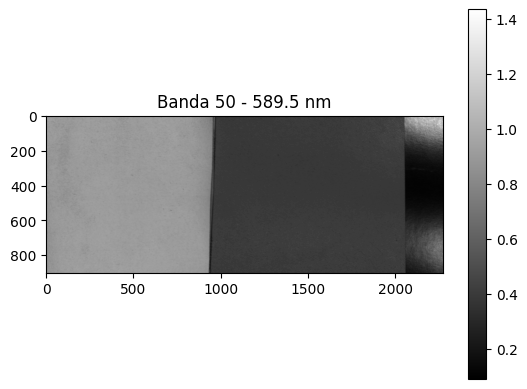

In [23]:
cube = load_spectral_image("/Volumes/Lexar/textiles/pelle/041-042.bil")
import matplotlib.pyplot as plt

band_idx = 50

img = cube.data[0, band_idx]  # (H, W)

plt.imshow(img.cpu(), cmap="gray")
plt.title(f"Banda {band_idx} - {cube.wavelengths[band_idx]:.1f} nm")
plt.colorbar()
plt.show()